# Neural ODEs Notebook

## Imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchdiffeq import odeint

## Data Preparation

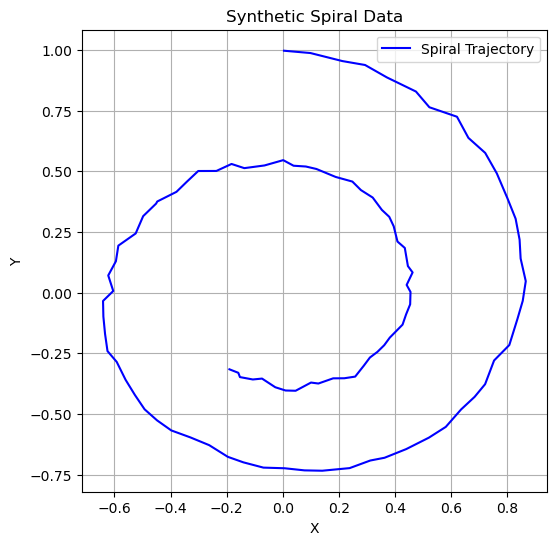

In [7]:
def generate_spiral_data(t, noise_std=0.01):
    x = np.sin(t) * np.exp(-0.1 * t)
    y = np.cos(t) * np.exp(-0.1 * t)
    x = x + np.random.normal(0, noise_std, size=t.shape)
    y = y + np.random.normal(0, noise_std, size=t.shape)
    return np.stack([x, y], axis=-1)  # shape (T, 2)

t = np.linspace(0, 10, 100)
data = generate_spiral_data(t)  # shape (100, 2)

plt.figure(figsize=(6, 6))
plt.plot(data[:, 0], data[:, 1], label="Spiral Trajectory", color="blue")
plt.title("Synthetic Spiral Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.show()

## ODE Function Definition

$$\frac{d\mathbf{y}(t)}{dt} = f_\theta(\mathbf{y}(t), t) = \text{Linear}(2 \to 50) \xrightarrow{\tanh} \text{Linear}(50 \to 2)$$

In [8]:
class ODEFunc(nn.Module):
    """Neural network that parameterizes dy/dt = f(y, t)."""

    def __init__(self):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 2),
        )

    def forward(self, t, y):
        return self.net(y)

## Neural ODE Model

In [9]:
class NeuralODE(nn.Module):
    """Wraps an ODE function and solves it with torchdiffeq (Tsit5 solver)."""

    def __init__(self, ode_func):
        super(NeuralODE, self).__init__()
        self.ode_func = ode_func

    def forward(self, y0, ts):
        return odeint(self.ode_func, y0, ts)

## Example Usage

In [10]:
ode_func = ODEFunc()
model = NeuralODE(ode_func)

y0_example = torch.tensor(data[0], dtype=torch.float32)
ts_tensor = torch.tensor(t, dtype=torch.float32)

predicted = model(y0_example, ts_tensor)
print(f"Predicted trajectory shape: {predicted.shape}")  # Expected: (100, 2)

Predicted trajectory shape: torch.Size([100, 2])


## Training

In [11]:
# Prepare tensors
ts_tensor = torch.tensor(t, dtype=torch.float32)
true_trajectory = torch.tensor(data, dtype=torch.float32)  # shape (100, 2)
y0 = true_trajectory[0]  # initial condition

# Hyperparameters
num_epochs = 1000
print_every = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    predicted_trajectory = model(y0, ts_tensor)
    loss = criterion(predicted_trajectory, true_trajectory)
    loss.backward()
    optimizer.step()

    if epoch % print_every == 0:
        print(f"Epoch {epoch:4d}, Loss: {loss.item():.6f}")

Epoch    0, Loss: 1.581103
Epoch  100, Loss: 0.106990
Epoch  200, Loss: 0.000512
Epoch  300, Loss: 0.000430
Epoch  400, Loss: 0.000366
Epoch  500, Loss: 0.000315
Epoch  600, Loss: 0.000275
Epoch  700, Loss: 0.000244
Epoch  800, Loss: 0.000219
Epoch  900, Loss: 0.000199


## Metrics and Visualization

In [12]:
predicted_trajectory = model(y0, ts_tensor).detach()

rmse = torch.sqrt(F.mse_loss(predicted_trajectory, true_trajectory))
print(f"RMSE: {rmse.item():.6f}")

RMSE: 0.013530


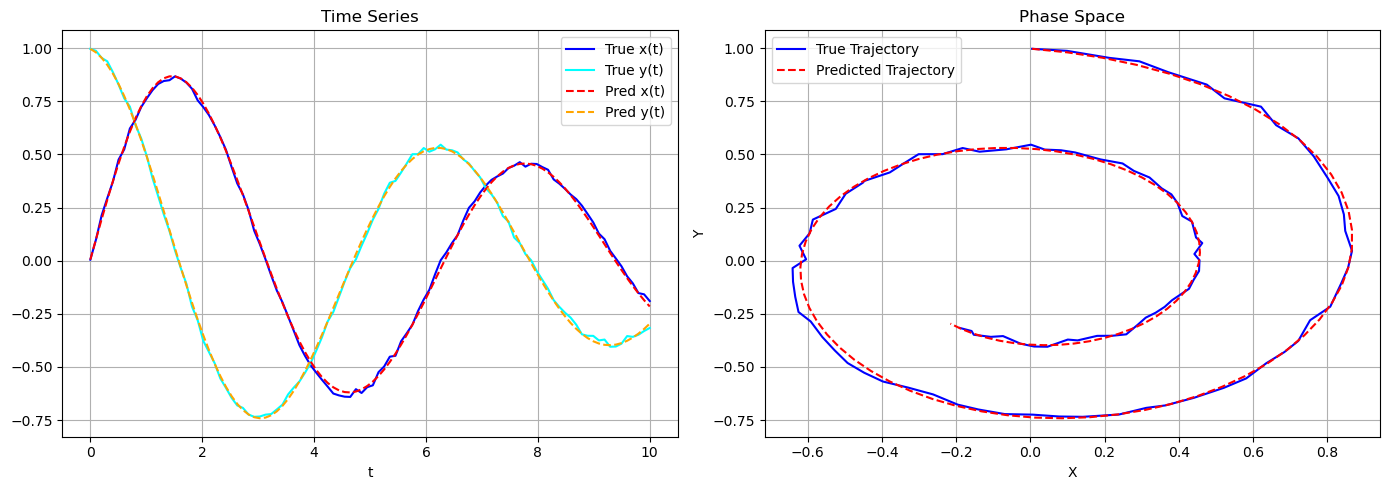

In [ ]:
true_np = true_trajectory.numpy()
pred_np = predicted_trajectory.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time-series plot
axes[0].plot(t, true_np[:, 0], label="True x(t)", color="blue")
axes[0].plot(t, true_np[:, 1], label="True y(t)", color="cyan")
axes[0].plot(t, pred_np[:, 0], label="Pred x(t)", color="red", linestyle="--")
axes[0].plot(t, pred_np[:, 1], label="Pred y(t)", color="orange", linestyle="--")
axes[0].set_title("Time Series")
axes[0].set_xlabel("t")
axes[0].legend()
axes[0].grid()

# Phase-space plot        # method='tsit5' matches the diffrax Tsit5 solver used in the JAX version

axes[1].plot(true_np[:, 0], true_np[:, 1], label="True Trajectory", color="blue")
axes[1].plot(pred_np[:, 0], pred_np[:, 1], label="Predicted Trajectory", color="red", linestyle="--")
axes[1].set_title("Phase Space")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()